### Домашняя работа

**Задание простого уровня** Загрузите данные из файла `non_linear.csv` и сгенерируйте данные до степени *degree = 8* включительно. Обучите модель `sklearn.linear_model.Lasso` и модель `sklearn.linear_model.Ridge` на полученных данных, используйте коэффициент регуляризации $\alpha=0.8$ для обеих моделей. Постройте два столбчатых графика, на которых отобразите величину коэффициентов для Ridge регрессии и Lasso регрессии в виде столбиков.

Пример графиков для 3-й степени (просто для примера, у вас может по-другому выглядеть). Какой можно сделать в вывод по величине коэффициентов?:
![coeff_example](https://pp.userapi.com/c850136/v850136613/19282c/OfwruuxOkPw.jpg)

# Новый раздел

# Новый раздел

In [51]:
import numpy as np
import pandas as pd

data = pd.read_csv('non_linear.csv', sep=',')
data.head()



,x_train,y_train
0,0.138368,0.838812
1,0.157237,0.889313
2,0.188684,1.430040
3,0.685553,1.717309
4,0.874237,2.032588


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

def generate_degrees(source_data: list, degree: int):
    """Функция, которая принимает на вход одномерный массив, а возвращает n-мерный
    Для каждой степени от 1 до  degree возводим x в эту степень
    """
    return np.array([
          source_data**n for n in range(1, degree + 1)
    ]).T

In [53]:
#получаем списки значений MSE при различных степенях полинома
Ridge_val = []
Ridge_tr = []
degree = 8
for i in range(degree):
    X = generate_degrees(data['x_train'], i + 1)
    y = data.y_train.values
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=10)
    model = Ridge(alpha=0.8).fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    y_pred_train = model.predict(X_train)

    Ridge_val_char = mean_squared_error(y_valid, y_pred)
    Ridge_val.append(Ridge_val_char)
    Ridge_tr_char = mean_squared_error(y_train, y_pred_train)
    Ridge_tr.append(Ridge_tr_char)

print("Качество на валидации: " , Ridge_val)
print("Качество на обучении: " , Ridge_tr)

Качество на валидации:  [0.26919180446486446, 0.25261629929815543, 0.07051585592384012, 0.06353172279411667, 0.06757626705252635, 0.07055460552383107, 0.07128982645975226, 0.07852416477772005]
Качество на обучении:  [0.3177572490910614, 0.3141495810537053, 0.10027093520055792, 0.10562556349624726, 0.0816039962795628, 0.08357012081088873, 0.06817542455890188, 0.070210382768639]


In [54]:
#получаем списки значений MSE при различных степенях полинома
Lasso_val = []
Lasso_tr = []
degree = 8
for i in range(degree):
    X = generate_degrees(data['x_train'], i + 1)
    y = data.y_train.values
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=10)
    model = Lasso(alpha=0.8).fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    y_pred_train = model.predict(X_train)

    Lasso_val_char = mean_squared_error(y_valid, y_pred)
    Lasso_val.append(Lasso_val_char)
    Lasso_tr_char =mean_squared_error(y_train, y_pred_train)
    Lasso_tr.append(Lasso_tr_char)
print("Качество на валидации: " , Lasso_val)
print("Качество на обучении: " , Lasso_tr)

Качество на валидации:  [0.6452171814549879, 0.3647191475847706, 0.3647191475847706, 0.11181014096308625, 0.09387726231727031, 0.10238035819364262, 0.09884980614274963, 0.09284713448746973]
Качество на обучении:  [0.5422351119428873, 0.35830065788985294, 0.35830065788985294, 0.1647511115675342, 0.1577309761244569, 0.16880441187958403, 0.16407832466856737, 0.15517204462175113]


C:\Users\user0907\AppData\Local\anaconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.365e-01, tolerance: 2.448e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\user0907\AppData\Local\anaconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.198e-01, tolerance: 2.448e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\user0907\AppData\Local\anaconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

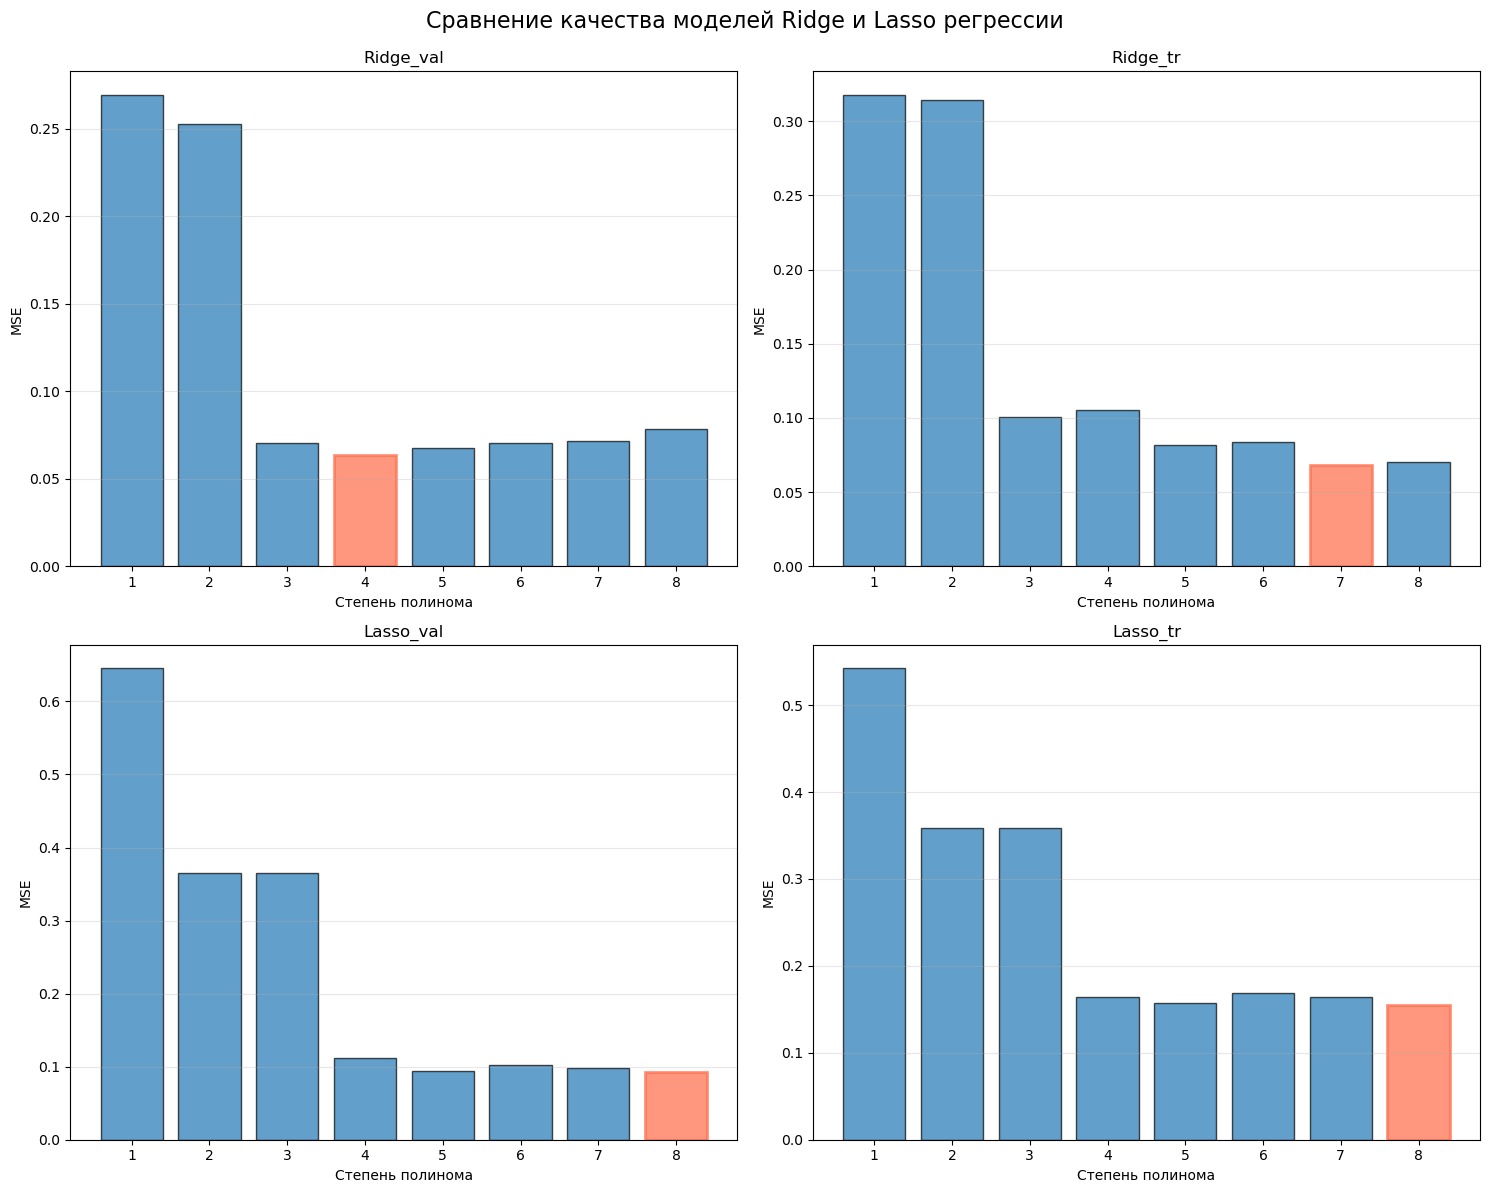

In [65]:
labels = ['Ridge_val', 'Ridge_tr', 'Lasso_val', 'Lasso_tr'] 
degrees = list(range(1, len(Ridge_val) + 1))
list_detect = [Ridge_val, Ridge_tr, Lasso_val, Lasso_tr]



#создаем фигуру с 4 подграфиками
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle('Сравнение качества моделей Ridge и Lasso регрессии', fontsize=16, y=0.99)
for i, (data, label) in enumerate(zip(list_detect, labels)):
    #определяем позицию на сетке 2x2
    row = i // 2
    col = i % 2
    
    #выбираем текущую ось
    ax = axs[row, col]
    
    #строим столбчатую диаграмму
    bars = ax.bar(degrees, data,  alpha=0.7, edgecolor='black')

    #настраиваем каждый подграфик
    ax.set_xlabel('Степень полинома')
    ax.set_ylabel('MSE')
    ax.set_title(f'{label}')
    ax.set_xticks(degrees)
    ax.grid(axis='y', alpha=0.3)
    
    #находим минимальное значение и выделяем его
    min_val = min(data)
    min_index = data.index(min_val)
    bars[min_index].set_color('#FF6A47')  #выделяем другим цветом
    bars[min_index].set_linewidth(2)

plt.tight_layout()
plt.show()

In [ ]:
#вывод: визуально видно, что для Lasso регрессии подходит максимальная степень полинома, а для Ridge - средняя

([0, 1, 2, 3],
 [Text(0, 0, 'Ridge_val'),
  Text(1, 0, 'Ridge_tr'),
  Text(2, 0, 'Lasso_val'),
  Text(3, 0, 'Lasso_tr')])

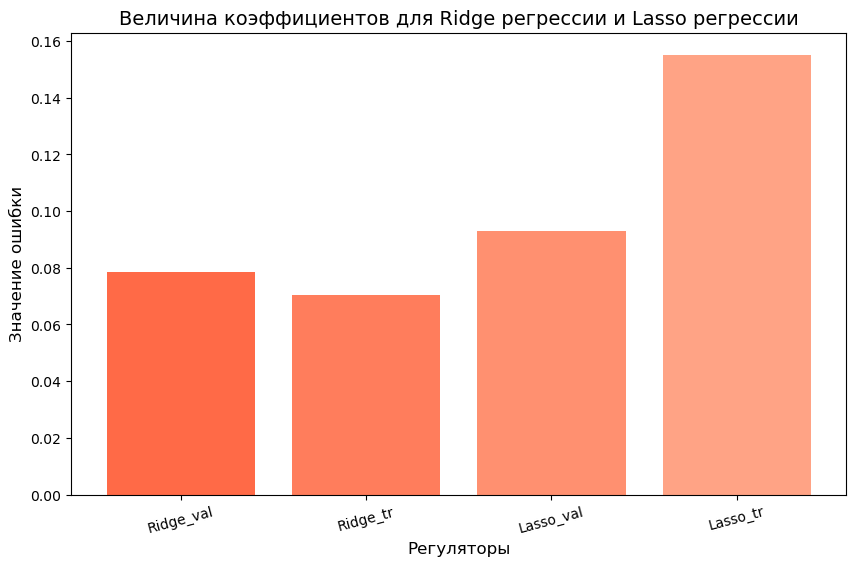

In [66]:
import matplotlib.pyplot as plt
#данные для столбцов
in_bar = [Ridge_val_char, Ridge_tr_char, Lasso_val_char, Lasso_tr_char]
#подписи для каждого столбца
labels = ['Ridge_val', 'Ridge_tr', 'Lasso_val', 'Lasso_tr'] 
#настройка графика
plt.figure(figsize=(10, 6))
plt.bar(labels, in_bar, color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699'])
plt.title('Величина коэффициентов для Ridge регрессии и Lasso регрессии', fontsize=14)
plt.xlabel('Регуляторы', fontsize=12)
plt.ylabel('Значение ошибки', fontsize=12)
plt.xticks(rotation=15)

Пока что мы пользуемся моделями с регуляризацией как "черным ящиком" - знаем, как применять и это работает! Для успешного решения задач этого достаточно. Если вам, как и мне, интересно *почему* это работает - добро пожаловать во второй урок, где Вас ждёт больше кода и формул!